In [28]:
import requests, json
import pandas as pd
import numpy as np

In [2]:
def RREO(an_exercicio, nr_periodo, co_tipo_demonstrativo, no_anexo, id_ente):
    url = f'https://apidatalake.tesouro.gov.br/ords/siconfi/tt//rreo?an_exercicio={an_exercicio}&nr_periodo={nr_periodo}&co_tipo_demonstrativo={co_tipo_demonstrativo}&no_anexo={no_anexo}&co_esfera=&id_ente={id_ente}'
    response = requests.get(url)
    if(response.status_code != 200): 
            return({result:'Falhou'})
    dados = response.json()
    return pd.DataFrame(dados['items'])

In [3]:
an_exercicio = ['2023','2024']
id_ente = "43" #Código IBGE do Ente. rondonia 11 sao paulo 35 RS 43
co_tipo_demonstrativo = 'RREO' #tipo de demonstrativo RREO - Bimestre
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = ['RREO-Anexo 01','RREO-Anexo 03','RREO-Anexo 06'] #'RREO-Anexo 13', 'RREO-Anexo 04', 'RREO-Anexo 11', 'RREO-Anexo 09', 'RREO-Anexo 02', 'RREO-Anexo 07','RREO-Anexo 14', 'RREO-Anexo 06', 'RREO-Anexo 10 - RPPS']

rreo_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RREO(i, nr_periodo, co_tipo_demonstrativo, j, id_ente)
        rreo_df = pd.concat([rreo_df, df])    

In [121]:
rreo_df.sample(2)

,exercicio,demonstrativo,periodo,periodicidade,instituicao,cod_ibge,uf,populacao,anexo,esfera,rotulo,coluna,cod_conta,conta,valor
71,2023,RREO,6,B,Governo do Estado de Rondônia,11,RO,1815278,RREO-Anexo 04,E,Padrão,PREVISÃO ATUALIZADA (a),TotalDasReceitasDaAdministracaoRPPS,TOTAL DAS RECEITAS DA ADMINISTRAÇÃO RPPS - (XII),5.835251e+07
486,2020,RREO,6,B,Governo do Estado de Rondônia,11,RO,1777225,RREO-Anexo 10 - RPPS,E,Padrão,RESULTADO PREVIDENCIÁRIO (c) = (a - b),ResultadoPrevidenciarioPlanoFinanceiro,2055,-6.350473e+08


In [126]:
#CONSULTA SEPARADA PARA TRATAMENTO

an_exercicio = ['2024']
id_ente = "11" #Código IBGE do Ente. rondonia 11 sao paulo 35
co_tipo_demonstrativo = 'RREO' #tipo de demonstrativo RREO - Bimestre
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = ['RREO-Anexo 01','RREO-Anexo 03','RREO-Anexo 13', 'RREO-Anexo 04', 'RREO-Anexo 11', 'RREO-Anexo 09', 'RREO-Anexo 02', 'RREO-Anexo 07','RREO-Anexo 14', 'RREO-Anexo 06', 'RREO-Anexo 10 - RPPS']

rreo_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RREO(i, nr_periodo, co_tipo_demonstrativo, j, id_ente)
        rreo_df = pd.concat([rreo_df, df])   

cod_contas_list = rreo_df[['anexo', 'cod_conta','conta','coluna','valor']]
cod_contas_list.to_excel('lista cod contas.xlsx')

In [4]:
#Tratamento dos dados

drop = rreo_df.columns[1:11]
rreo_df = rreo_df.drop(columns=drop)

rreo_df['coluna'] = np.where(rreo_df['coluna'].str.contains('PREVISÃO ATUALIZADA'), 'PREVISÃO ATUALIZADA', rreo_df['coluna'])

rreo_df_pivot = rreo_df.pivot_table(index=['exercicio','cod_conta'], columns='coluna', values='valor', aggfunc='sum')

rreo_df_pivot.fillna(0, inplace=True)


In [ ]:
rreo_df_pivot.sample(5)

coluna                                          % (b/a)  % (c/a)  <MR-10>  \
exercicio cod_conta                                                         
2020      RREO6ReceitasDeCapital                    0.0      0.0      0.0   
2021      RREO6DemaisReceitasCorrentes              0.0      0.0      0.0   
2023      DespesasExcetoIntraOrcamentarias          0.0      0.0      0.0   
          OutrasAlienacoesDeBens                    0.0      0.0      0.0   
2024      DespesaPrimariaTotalExcetoFontesRPPS      0.0      0.0      0.0   

coluna                                          <MR-11>  <MR-1>  <MR-2>  \
exercicio cod_conta                                                       
2020      RREO6ReceitasDeCapital                    0.0     0.0     0.0   
2021      RREO6DemaisReceitasCorrentes              0.0     0.0     0.0   
2023      DespesasExcetoIntraOrcamentarias          0.0     0.0     0.0   
          OutrasAlienacoesDeBens                    0.0     0.0     0.0   
2024      DespesaPrimariaTotalExcetoFontesRPPS      0.0     0.0     0.0   

coluna                                          <MR-3>  <MR-4>  <MR-5>  \
exercicio cod_conta                                                      
2020      RREO6ReceitasDeCapital                   0.0     0.0     0.0   
2021      RREO6DemaisReceitasCorrentes             0.0     0.0     0.0   
2023      DespesasExcetoIntraOrcamentarias         0.0     0.0     0.0   
          OutrasAlienacoesDeBens                   0.0     0.0     0.0   
2024      DespesaPrimariaTotalExcetoFontesRPPS     0.0     0.0     0.0   

coluna                                          <MR-6>  ...  \
exercicio cod_conta                                     ...   
2020      RREO6ReceitasDeCapital                   0.0  ...   
2021      RREO6DemaisReceitasCorrentes             0.0  ...   
2023      DespesasExcetoIntraOrcamentarias         0.0  ...   
          OutrasAlienacoesDeBens                   0.0  ...   
2024      DespesaPrimariaTotalExcetoFontesRPPS     0.0  ...   

coluna                                          PREVISÃO ORÇAMENTÁRIA  \
exercicio cod_conta                                                     
2020      RREO6ReceitasDeCapital                                  0.0   
2021      RREO6DemaisReceitasCorrentes                            0.0   
2023      DespesasExcetoIntraOrcamentarias                        0.0   
          OutrasAlienacoesDeBens                                  0.0   
2024      DespesaPrimariaTotalExcetoFontesRPPS                    0.0   

coluna                                          RECEITAS REALIZADAS (a)  \
exercicio cod_conta                                                       
2020      RREO6ReceitasDeCapital                           6.581357e+07   
2021      RREO6DemaisReceitasCorrentes                     6.658039e+08   
2023      DespesasExcetoIntraOrcamentarias                 0.000000e+00   
          OutrasAlienacoesDeBens                           8.674135e+06   
2024      DespesaPrimariaTotalExcetoFontesRPPS             0.000000e+00   

coluna                                          RESTOS A PAGAR PROCESSADOS PAGOS (b)  \
exercicio cod_conta                                                                    
2020      RREO6ReceitasDeCapital                                                0.00   
2021      RREO6DemaisReceitasCorrentes                                          0.00   
2023      DespesasExcetoIntraOrcamentarias                                      0.00   
          OutrasAlienacoesDeBens                                                0.00   
2024      DespesaPrimariaTotalExcetoFontesRPPS                           93430715.46   

coluna                                          SALDO (a-c)  \
exercicio cod_conta                                           
2020      RREO6ReceitasDeCapital                        0.0   
2021      RREO6DemaisReceitasCorrentes                  0.0   
2023      DespesasExcetoIntraOrcamentarias              0.0   
   

In [52]:
#Tabela 1

import pandas as pd

def get_value(exercicio, cod_conta, coluna):
    try:
        return round(rreo_df_pivot.loc[(exercicio, cod_conta), coluna] / 1_000_000, 2) #em milhões
    except KeyError:
        return 0  # Retorna 0 caso a conta ou a coluna não existam
    
def format_negative(x):
    if isinstance(x, (int, float)):
        if x < 0:
            return f"({abs(x)})"
        return str(x)
    return x

exercicio = 2024
exercicio_anterior = exercicio - 1

tabela_1 = pd.DataFrame({
    'RECEITAS': [
        'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA',
        'CONTRIBUIÇÕES',
        'RECEITA PATRIMONIAL',
        'RECEITA AGROPECUÁRIA',
        'RECEITA INDUSTRIAL',
        'RECEITA DE SERVIÇOS',
        'TRANSFERÊNCIAS CORRENTES',
        'OUTRAS RECEITAS CORRENTES',
        'DEDUÇÕES',
        '( - ) Deduções para o FUNDEB',
        '( - ) Deduções para os Municípios',
        '( - ) Demais Deduções',
        'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'OPERAÇÕES DE CRÉDITO',
        'ALIENAÇÃO DE BENS',
        'AMORTIZAÇÕES DE EMPRÉSTIMOS',
        'TRANSFERÊNCIAS DE CAPITAL',
        'OUTRAS RECEITAS DE CAPITAL',
        'SUBTOTAL DAS RECEITAS',
        'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO',
        'TOTAL DAS RECEITAS (LÍQUIDA)'                      
    ],
    'PREVISÃO ATUALIZADA (A)': [
        0,
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaDeContribuicoes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaPatrimonial', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaAgropecuaria', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaIndustrial', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaDeServicos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasCorrentes', 'PREVISÃO ATUALIZADA'),
        0,
        -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'PREVISÃO ATUALIZADA'),
        -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'PREVISÃO ATUALIZADA'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AlienacaoDeBens', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'TransferenciasDeCapital', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'PREVISÃO ATUALIZADA'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0
    ],
    f'ARRECADADO (B) {exercicio}': [
        0,
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ReceitaDeContribuicoes', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaPatrimonial', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaAgropecuaria', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaIndustrial', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaDeServicos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'OutrasReceitasCorrentes', 'Até o Bimestre (c)'),
        0,
        -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0                
    ],
    '% (C) = B/A': [0] * 22,
    f'{exercicio_anterior} (D)': [
        0,
        get_value(exercicio_anterior, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ReceitaDeContribuicoes', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaPatrimonial', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaAgropecuaria', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaIndustrial', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaDeServicos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'OutrasReceitasCorrentes', 'Até o Bimestre (c)'),
        0,
        -get_value(exercicio_anterior, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        -get_value(exercicio_anterior, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio_anterior, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0                
    ],
    'Var. Nom. (%) E = (B/D) -1': [0] * 22
})

# calcula somas
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', 'PREVISÃO ATUALIZADA (A)'] = tabela_1.loc[9:12, 'PREVISÃO ATUALIZADA (A)'].sum()
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'ARRECADADO (B) {exercicio}'] = tabela_1.loc[9:12, f'ARRECADADO (B) {exercicio}'].sum()
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'{exercicio_anterior} (D)'] = tabela_1.loc[9:12, f'{exercicio_anterior} (D)'].sum()

tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'] = (tabela_1.loc[1:11, 'PREVISÃO ATUALIZADA (A)'].sum()-
                                                                                                                      tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', 'PREVISÃO ATUALIZADA (A)'].values[0])
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'] = (tabela_1.loc[1:11, f'ARRECADADO (B) {exercicio}'].sum()-
                                                                                                                          tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'ARRECADADO (B) {exercicio}'].values[0])
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'] = (tabela_1.loc[1:11, f'{exercicio_anterior} (D)'].sum()-
                                                                                                                        tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'{exercicio_anterior} (D)'].values[0])

tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'] = tabela_1.loc[14:20, 'PREVISÃO ATUALIZADA (A)'].sum().round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'] = tabela_1.loc[14:20, f'ARRECADADO (B) {exercicio}'].sum().round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'] = tabela_1.loc[14:20, f'{exercicio_anterior} (D)'].sum().round(2)

tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'].values[0]
    ).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'ARRECADADO (B) {exercicio}'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'].values[0]
    ).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'{exercicio_anterior} (D)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'].values[0]
    ).round(2)

tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', 'PREVISÃO ATUALIZADA (A)'].values[0]
)
tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', f'ARRECADADO (B) {exercicio}'].values[0]
)
tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'{exercicio_anterior} (D)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', f'{exercicio_anterior} (D)'].values[0]
)

# calcula a porcentagem das colunas
tabela_1['% (C) = B/A'] = (tabela_1[f'ARRECADADO (B) {exercicio}'] / tabela_1['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_1['% (C) = B/A'] = tabela_1['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_1['Var. Nom. (%) E = (B/D) -1'] = (
    abs((tabela_1[f'ARRECADADO (B) {exercicio}'] / tabela_1[f'{exercicio_anterior} (D)']) - 1) * 100
)
tabela_1['Var. Nom. (%) E = (B/D) -1'] = tabela_1['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_1[col] = tabela_1[col].apply(format_negative)

tabela_1

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS),60216.22,64089.31,106.43 %,60574.55,5.8 %
1,"IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA",59706.44,64337.57,107.76 %,57620.3,11.66 %
2,CONTRIBUIÇÕES,6007.37,6000.24,99.88 %,5484.01,9.41 %
3,RECEITA PATRIMONIAL,1926.76,1933.11,100.33 %,4117.91,53.06 %
4,RECEITA AGROPECUÁRIA,1.3,0.22,16.92 %,0.37,40.54 %
5,RECEITA INDUSTRIAL,0.01,0.0,0.0 %,0.0,0.0 %
6,RECEITA DE SERVIÇOS,603.98,593.19,98.21 %,559.58,6.01 %
7,TRANSFERÊNCIAS CORRENTES,14335.99,14873.57,103.75 %,14607.13,1.82 %
8,OUTRAS RECEITAS CORRENTES,1070.79,1479.58,138.18 %,1109.91,33.31 %
9,DEDUÇÕES,(23436.42),(25128.17),107.22 %,(22924.66),9.61 %


In [30]:
#tabela_2


tabela_2 = pd.DataFrame({
    'RECEITAS': [
        'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA',
        'ICMS',
        'IPVA',
        'ITCD',
        'IRRF',
        'Outras Receitas Tributárias',
        '(-) Deduções dos Impostos',
        'TOTAL DAS RECEITAS (LÍQUIDA)'
    ],
    'PREVISÃO ATUALIZADA (A)' : [
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasTributarias', 'PREVISÃO ATUALIZADA'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ],
    f'ARRECADADO (B) {exercicio}' :[
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'OutrasReceitasTributarias', 'TOTAL (ÚLTIMOS 12 MESES)'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ],
    '% (C) = B/A': [0] * 8,
    f'{exercicio_anterior} (D)' :[
        get_value(exercicio_anterior, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'OutrasReceitasTributarias', 'TOTAL (ÚLTIMOS 12 MESES)'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ]
    })


#Total das Deduções - 
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', 'PREVISÃO ATUALIZADA (A)'] = (
    -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'PREVISÃO ATUALIZADA')
    -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'PREVISÃO ATUALIZADA')
)
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'ARRECADADO (B) {exercicio}'] = (
    -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)') 
    -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)')   
)
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'{exercicio_anterior} (D)'] = (
    -get_value(exercicio_anterior, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio_anterior, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)')    
)



#Total da Receita Líquida
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', 'PREVISÃO ATUALIZADA (A)'].values[0]
)
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'ARRECADADO (B) {exercicio}'].values[0]
)
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', f'{exercicio_anterior} (D)'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'{exercicio_anterior} (D)'].values[0]
)

# calcula a porcentagem das colunas
tabela_2['% (C) = B/A'] = (tabela_2[f'ARRECADADO (B) {exercicio}'] / tabela_2['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_2['% (C) = B/A'] = tabela_2['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_2['Var. Nom. (%) E = (B/D) -1'] = ((tabela_2[f'ARRECADADO (B) {exercicio}'] / tabela_2[f'{exercicio_anterior} (D)']) - 1) * 100
tabela_2['Var. Nom. (%) E = (B/D) -1'] = tabela_2['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'


for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_2[col] = tabela_2[col].apply(format_negative)


tabela_2

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,"IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA",59706.44,64337.57,107.76 %,57620.3,11.66 %
1,ICMS,46870.0,50610.92,107.98 %,44865.77,12.81 %
2,IPVA,5234.0,5478.86,104.68 %,5109.58,7.23 %
3,ITCD,1129.0,1656.5,146.72 %,1430.89,15.77 %
4,IRRF,3872.11,3810.31,98.4 %,3631.76,4.92 %
5,Outras Receitas Tributárias,2601.33,2780.98,106.91 %,2582.31,7.69 %
6,(-) Deduções dos Impostos,(23436.42),(25128.17),107.22 %,(22924.66),9.61 %
7,TOTAL DAS RECEITAS (LÍQUIDA),36270.020000000004,39209.4,108.1 %,34695.64,13.01 %


In [51]:
# Tabela 3

tabela_3 = pd.DataFrame({
    'RECEITAS': [
        'Transferências Correntes',
        'Cota-Parte do Fundo de Participação dos Estados e do Distrito Federal - FPE',
        'IPI-Exportação',
        'FUNDEB',
        'Outras Transferências Correntes',
        '(-) Deduções das Transferências Correntes',
        'TRANSFERÊNCIAS CORRENTES LÍQUIDAS'
    ],
    'PREVISÃO ATUALIZADA (A)': [
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3CotaParteDoFPE', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3TransferenciasDaLC611989', 'PREVISÃO ATUALIZADA'), # IPI
        get_value(exercicio, 'RREO3TransferenciasDoFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3OutrasTransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        0,  # Deduções
        get_value(exercicio, 'RREO6TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),   # Transferências Correntes
    ],
    f'ARRECADADO (B) {exercicio}': [
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3CotaParteDoFPE', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3TransferenciasDaLC611989', 'TOTAL (ÚLTIMOS 12 MESES)'), # IPI
        get_value(exercicio, 'RREO3TransferenciasDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3OutrasTransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0,  # Deduções
        get_value(exercicio, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')   # Transferências Correntes
    ],
    '% (C) = B/A': [0] * 7,
    f'{exercicio_anterior} (D)': [
        get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3CotaParteDoFPE', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3TransferenciasDaLC611989', 'TOTAL (ÚLTIMOS 12 MESES)'), # IPI
        get_value(exercicio_anterior, 'RREO3TransferenciasDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3OutrasTransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0,  # Deduções
        get_value(exercicio_anterior, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')   # Transferências Correntes
    ]
})

# calculo deduções utilizando a diferença entre as contas, verificar as contas respectivas
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', 'PREVISÃO ATUALIZADA (A)'] = -(
    get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA')
    -get_value(exercicio, 'RREO6TransferenciasCorrentes', 'PREVISÃO ATUALIZADA')
).round(2)
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', f'ARRECADADO (B) {exercicio}'] = -(
    get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')
).round(2)
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', f'{exercicio_anterior} (D)'] = -(
    get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio_anterior, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')
).round(2)



# calulo porcentagens
tabela_3['% (C) = B/A'] = (tabela_3[f'ARRECADADO (B) {exercicio}'] / tabela_3['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_3['% (C) = B/A'] = tabela_3['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_3['Var. Nom. (%) E = (B/D) -1'] = ((tabela_3[f'ARRECADADO (B) {exercicio}'] / tabela_3[f'{exercicio_anterior} (D)']) - 1) * 100
tabela_3['Var. Nom. (%) E = (B/D) -1'] = tabela_3['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

# formato negativo numeros
for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_3[col] = tabela_3[col].apply(format_negative)


tabela_3

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,Transferências Correntes,14335.99,14873.57,103.75 %,14607.13,1.82 %
1,Cota-Parte do Fundo de Participação dos Estado...,3702.47,3770.73,101.84 %,3209.47,17.49 %
2,IPI-Exportação,478.09,644.97,134.91 %,436.86,47.64 %
3,FUNDEB,6189.71,6431.8,103.91 %,5844.69,10.05 %
4,Outras Transferências Correntes,3965.73,4026.08,101.52 %,5116.1,-21.31 %
5,(-) Deduções das Transferências Correntes,(1480.82),(1295.43),87.48 %,(1756.14),-26.23 %
6,TRANSFERÊNCIAS CORRENTES LÍQUIDAS,12855.17,13578.14,105.62 %,12850.99,5.66 %


In [ ]:
# Tabela 4 - adicionar as subreceitas de capital

tabela_4 = pd.DataFrame({
    'RECEITAS': [
        'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'OPERAÇÕES DE CRÉDITO',
        'ALIENAÇÃO DE BENS',
        'AMORTIZAÇÕES DE EMPRÉSTIMOS',
        'TRANSFERÊNCIAS DE CAPITAL',
        'OUTRAS RECEITAS DE CAPITAL',
    ],
    'PREVISÃO ATUALIZADA (A)': [
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AlienacaoDeBens', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'TransferenciasDeCapital', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'PREVISÃO ATUALIZADA'),
    ],
    f'ARRECADADO (B) {exercicio}': [
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
    ],
    '% (C) = B/A': [0] * 6,
    f'{exercicio_anterior} (D)': [
        0,
        get_value(exercicio_anterior, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
    ],
    'Var. Nom. (%) E = (B/D) -1': [0] * 6
})

tabela_4.loc[tabela_4['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'] = tabela_4.loc[1:6, 'PREVISÃO ATUALIZADA (A)'].sum().round(2)
tabela_4.loc[tabela_4['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'] = tabela_4.loc[1:6, f'ARRECADADO (B) {exercicio}'].sum().round(2)
tabela_4.loc[tabela_4['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'] = tabela_4.loc[1:6, f'{exercicio_anterior} (D)'].sum().round(2)

# calcula a porcentagem das colunas
tabela_4['% (C) = B/A'] = (tabela_4[f'ARRECADADO (B) {exercicio}'] / tabela_4['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_4['% (C) = B/A'] = tabela_4['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_4['Var. Nom. (%) E = (B/D) -1'] = (
    abs((tabela_4[f'ARRECADADO (B) {exercicio}'] / tabela_4[f'{exercicio_anterior} (D)']) - 1) * 100
)
tabela_4['Var. Nom. (%) E = (B/D) -1'] = tabela_4['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_4


,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS),2902.18,1485.71,51.19 %,4325.02,65.65 %
1,OPERAÇÕES DE CRÉDITO,2580.35,1221.37,47.33 %,78.66,1452.72 %
2,ALIENAÇÃO DE BENS,109.49,42.64,38.94 %,4008.90,98.94 %
3,AMORTIZAÇÕES DE EMPRÉSTIMOS,9.04,34.32,379.65 %,20.73,65.56 %
4,TRANSFERÊNCIAS DE CAPITAL,194.70,186.76,95.92 %,186.70,0.03 %
5,OUTRAS RECEITAS DE CAPITAL,8.60,0.62,7.21 %,30.03,97.94 %


In [55]:
contas_receitas_correntes = [
    'ReceitaDeContribuicoes',
    'ReceitaPatrimonial',
    'ReceitaDeServicos',
    'OutrasReceitasCorrentes',
    'ReceitasIntraOrcamentariasTotal',
    'RREO3TransferenciasCorrentes',
    'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB',
]

contas_receitas_capital = [
    'ReceitasDeOperacoesDeCredito',
    'AlienacaoDeBens',
    'AmortizacoesDeEmprestimos',
    'TransferenciasDeCapital',
    'OutrasReceitasDeCapital'
    
]

filtro_receitas_correntes = rreo_df[rreo_df['cod_conta'].isin(contas_receitas_correntes)]
filtro_receitas_capital = rreo_df[rreo_df['cod_conta'].isin(contas_receitas_capital)]


# Agrupando por 'exercicio' e somando os valores
receitas_correntes_anexo01 = filtro_receitas_correntes.query("coluna == 'Até o Bimestre (c)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()
receitas_correntes_anexo03 = filtro_receitas_correntes.query("coluna == 'TOTAL (ÚLTIMOS 12 MESES)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()

receitas_capital = filtro_receitas_capital.query("coluna == 'Até o Bimestre (c)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()

receitas_brutas = pd.concat([receitas_correntes_anexo01, receitas_correntes_anexo03, receitas_capital]).groupby(['exercicio'])['valor'].sum().reset_index()

receitas_brutas['valor_bilhoes'] = (receitas_brutas['valor'] / 1000000000).round(2)

receitas_brutas

,exercicio,valor,valor_bilhoes
0,2023,1.048946e+11,104.89
1,2024,1.077628e+11,107.76


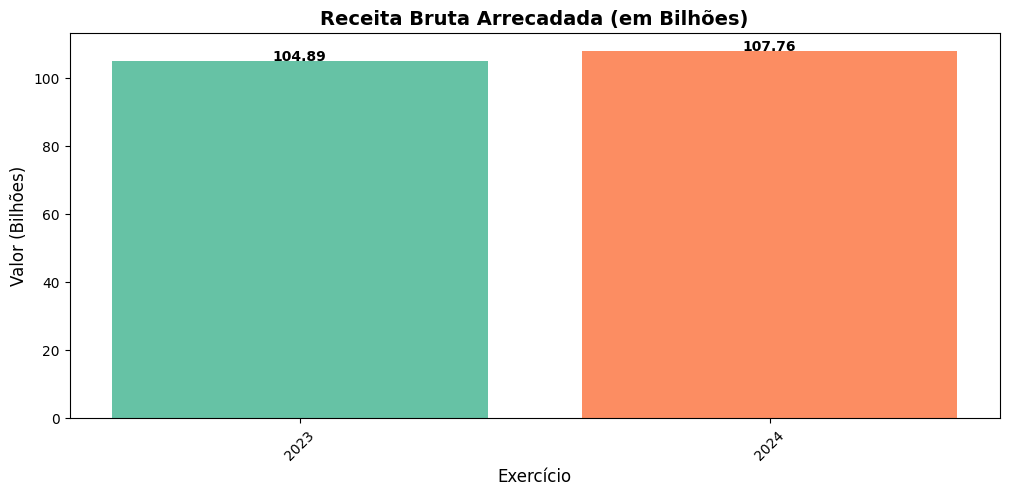

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo do gráfico
sns.set_style()  # Fundo mais limpo
plt.figure(figsize=(12, 5))  # Ajustando o tamanho

# Criando o gráfico de barras
cores = sns.color_palette("Set2", len(receitas_brutas))  # Paleta de cores
plt.bar(receitas_brutas['exercicio'], receitas_brutas['valor_bilhoes'], color=cores)

# Adicionando rótulos e título
plt.xlabel("Exercício", fontsize=12)
plt.ylabel("Valor (Bilhões)", fontsize=12)
plt.title("Receita Bruta Arrecadada (em Bilhões)", fontsize=14, fontweight="bold")

# Ajustando os rótulos do eixo X
plt.xticks(receitas_brutas['exercicio'], rotation=45)

# Adicionando rótulos nas barras
for i, valor in enumerate(receitas_brutas['valor_bilhoes']):
    plt.text(receitas_brutas['exercicio'][i], valor + 0.05, f"{valor:.2f}", 
             ha='center', fontsize=10, fontweight='bold', color='black')

plt.savefig('receita_bruta_arrecadada.png')

# Exibindo o gráfico
plt.show()



In [24]:
pip install python-docx


  Using cached python_docx-1.1.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
Using cached python_docx-1.1.2-py3-none-any.whl (244 kB)
Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)


In [31]:
from docx import Document
from docx.shared import Inches

# Criar um novo documento
doc = Document()

# Adicionar título
doc.add_heading('Relatório de Receitas', 0)

# Adicionar tabela de receitas correntes
doc.add_heading('Receitas Correntes', level=1)
table = doc.add_table(rows=1, cols=len(df_teste.columns))
hdr_cells = table.rows[0].cells
for i, column in enumerate(df_teste.columns):
    hdr_cells[i].text = column

for index, row in df_teste.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Adicionar gráfico
doc.add_heading('Gráfico de Receita Bruta Arrecadada', level=1)
doc.add_picture('receita_bruta_arrecadada.png', width=Inches(6))

# Salvar o documento
doc.save('Relatorio_Receitas.docx')